Code for the neural implementation of Kalman Temporal difference learning in Chapter 10 of Computational Foundations of Cognitive Neuroscience (https://gershmanlab.com/textbook/chapter4.pdf), applied to sensory preconditioning.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class ProbabilisticTD_Recurrent:
    """
    Neural approximation inspired by Gershman textbook Ch10 §7.4:
      - Recurrent preprocessing: y = (I - B)^-1 h  (Eq. 24–25)
      - Variance-normalized TD error: δ̄ = δ / (h^T Σ h + σ_r^2)  (Eq. 23 idea)
      - TD update uses transformed input y
    """

    def __init__(self, n, gamma=0.95, lr_w=0.10, lr_B=0.12, sigma_r=0.25,
                 lesion=False, spectral_clip=0.85, seed=0):
        self.n = n
        self.gamma = gamma
        self.lr_w = lr_w
        self.lr_B = lr_B
        self.sigma_r = sigma_r
        self.lesion = lesion
        self.spectral_clip = spectral_clip
        rng = np.random.default_rng(seed)

        self.w = np.zeros(n)
        self.B = rng.normal(scale=1e-6, size=(n, n))
        np.fill_diagonal(self.B, 0.0)
        if lesion:
            self.B[:] = 0.0

    def _stabilize_B(self):
        """Keep spectral radius < spectral_clip so (I-B) is invertible."""
        if self.lesion:
            return
        rho = np.max(np.abs(np.linalg.eigvals(self.B)))
        if rho > self.spectral_clip:
            self.B *= self.spectral_clip / (rho + 1e-12)

    def Sigma_hat(self):
        """Σ̂ ≈ (I - B)^-1 (proxy for covariance/associability transform)."""
        if self.lesion:
            return np.eye(self.n)
        self._stabilize_B()
        return np.linalg.inv(np.eye(self.n) - self.B)

    def transform(self, h):
        """y = (I - B)^-1 h (or y=h if lesioned)."""
        if self.lesion:
            return h.copy()
        return self.Sigma_hat() @ h

    def step(self, h_t, r_t, h_tp1, learn_structure=False):
        """
        One TD step: (h_t -> h_tp1) with reward r_t.
        If learn_structure=True, update B using co-activation (toy covariance-learning episode).
        """
        y_t = self.transform(h_t)
        y_tp1 = self.transform(h_tp1)

        V_t = self.w @ y_t
        V_tp1 = self.w @ y_tp1
        delta = r_t + self.gamma * V_tp1 - V_t

        Sigma = self.Sigma_hat()
        lam = float(h_t.T @ Sigma @ h_t + self.sigma_r**2)
        delta_bar = delta / lam

        # TD update using transformed input
        self.w += self.lr_w * y_t * delta_bar

        # Structure learning: update B ONLY on co-activation episodes (overlap steps)
        if (not self.lesion) and learn_structure:
            self.B += self.lr_B * (np.outer(h_t, h_t) - self.B)
            np.fill_diagonal(self.B, 0.0)
            self._stabilize_B()

        return delta, delta_bar, lam

def oh(i, n):
    v = np.zeros(n)
    v[i] = 1.0
    return v

In [3]:
def run_sensory_preconditioning_demo(seed=7, pre_trials=300, cond_trials=200):
    """
    Standard sensory preconditioning structure:
      Phase 1 (preconditioning): A->B and X->Y (no reward), with a brief overlap step to induce covariance.
      Phase 2 (conditioning): B->US (reward), ONLY B reinforced.
      Probe: Compare value for A vs X; measure representational similarity and pattern completion.
    """
    # Stimulus indices
    A, B, X, Y = 0, 1, 2, 3
    n = 4
    z = np.zeros(n)

    intact = ProbabilisticTD_Recurrent(n, lesion=False, seed=seed)
    lesion = ProbabilisticTD_Recurrent(n, lesion=True, seed=seed)

    def train(model):
        # Phase 1: preconditioning (no reward), with overlap steps that learn structure
        for _ in range(pre_trials):
            # A -> (A+B overlap) -> B
            model.step(oh(A,n), 0.0, oh(A,n)+oh(B,n), learn_structure=False)
            model.step(oh(A,n)+oh(B,n), 0.0, oh(B,n), learn_structure=True)  # learn A~B
            model.step(oh(B,n), 0.0, z, learn_structure=False)

            # X -> (X+Y overlap) -> Y  (control pair not reinforced later)
            model.step(oh(X,n), 0.0, oh(X,n)+oh(Y,n), learn_structure=False)
            model.step(oh(X,n)+oh(Y,n), 0.0, oh(Y,n), learn_structure=True)  # learn X~Y
            model.step(oh(Y,n), 0.0, z, learn_structure=False)

        # Phase 2: conditioning (ONLY B is reinforced)
        for _ in range(cond_trials):
            model.step(oh(B,n), 1.0, z, learn_structure=False)

        # Probe reps and values
        reps = {k: model.transform(oh(i,n)) for k,i in [('A',A),('B',B),('X',X),('Y',Y)]}
        V = {k: float(model.w @ reps[k]) for k in reps.keys()}

        # Representational similarity (cosine)
        keys = ['A','B','X','Y']
        cos = np.zeros((4,4))
        for i,k1 in enumerate(keys):
            for j,k2 in enumerate(keys):
                a, b = reps[k1], reps[k2]
                cos[i,j] = float(a @ b / (np.linalg.norm(a)+1e-12) / (np.linalg.norm(b)+1e-12))

        return V, reps, cos, model.B.copy(), model.Sigma_hat()

    V_i, reps_i, cos_i, B_i, Sigma_i = train(intact)
    V_l, reps_l, cos_l, B_l, Sigma_l = train(lesion)
    
    # --- Plots ---
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 15))
    
    # 1) Behavior: sensory preconditioning (A>0 only if intact)
    x = np.arange(2)
    ax1.axhline(0, linestyle='--', linewidth=1)
    ax1.plot([V_i['A'], V_i['X']], marker='o', label='Intact recurrent')
    ax1.plot([V_l['A'], V_l['X']], marker='o', label='Lesion recurrent')
    ax1.set_xticks(x)
    ax1.set_xticklabels(['A', 'X'])
    ax1.set_ylabel('Predicted value at probe')
    ax1.legend(frameon=False)
    ax1.set_xlim(-0.5, 1.5)
    ax1.set_box_aspect(1)

    # 3) Transformed unit activity for B (pattern completion)
    yB_intact = reps_i['B']
    yB_lesion = reps_l['B']
    yB_intact = np.asarray(yB_intact[:2])
    yB_lesion = np.asarray(yB_lesion[:2])

    labels = ('A','B')
    x = np.arange(len(labels))
    ax2.axhline(0, linestyle='--', linewidth=1)

    ax2.plot(
        yB_intact,
        marker='o',
        label='Intact recurrent'
    )

    ax2.plot(
        yB_lesion,
        marker='o',
        label='Lesion recurrent'
    )

    ax2.set_xticks(x)
    ax2.set_xticklabels(labels)
    ax2.set_xlim(-0.5, 1.5)
    ax2.set_ylabel('Transformed unit activity')
    ax2.set_box_aspect(1)
    
    # 2) OFC-like representational similarity (associative structure)
    ax3.imshow(cos_i, vmin=-1, vmax=1)
    ax3.set_xticks(range(4))
    ax3.set_xticklabels(['A','B','X','Y'])
    ax3.set_yticks(range(4))
    ax3.set_yticklabels(['A','B','X','Y'])
    ax3.set_box_aspect(1)

    plt.tight_layout()
    #plt.savefig("sensory_preconditioning.pdf", bbox_inches='tight')
    plt.show()

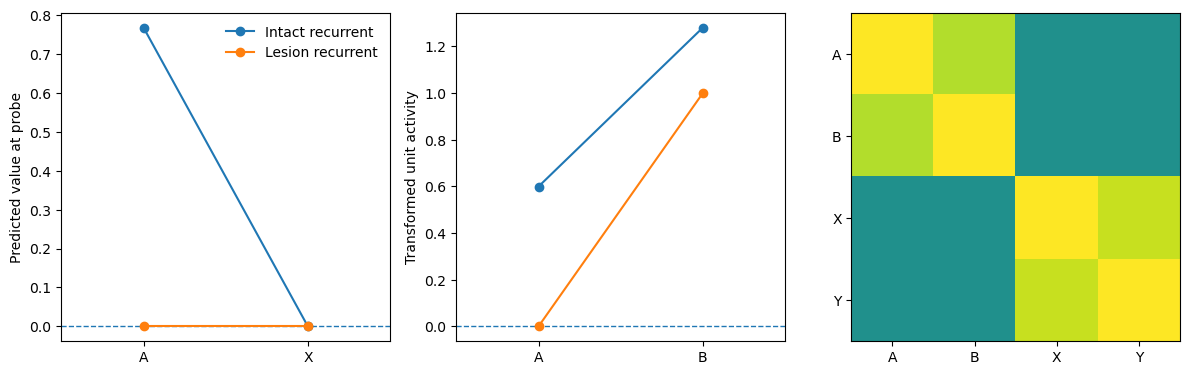

In [4]:
# Run the demo
run_sensory_preconditioning_demo()